<a href="https://colab.research.google.com/github/aditya-r21/Computer-Vision/blob/main/Noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

class NoisyDataset(Dataset):
  def __init__(self, mnist_dataset, noise_std=0.2):
    self.mnist = mnist_dataset
    self.noise_std = noise_std

  def __len__(self):
    return len(self.mnist)

  def __getitem__(self, idx):
    clean_image, label = self.mnist[idx]
    noise = torch.randn(clean_image.size()) * self.noise_std
    noisy_image = clean_image + noise
    return clean_image, noisy_image

from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
base_test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
base_train_dataset, base_val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_dataset = NoisyDataset(base_train_dataset, noise_std=0.3)
val_dataset = NoisyDataset(base_val_dataset, noise_std=0.3)
test_dataset = NoisyDataset(base_test_dataset, noise_std=0.3)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.96MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.15MB/s]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=True)

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def visualize_progress(clean, real_noisy, fake_noisy, epoch, num_images=8):
    """Plots a 3-row grid: Clean -> Real Noisy -> Generated Noisy"""

    # Grab just the first 'num_images' from the batch and move to CPU for plotting
    clean = clean[:num_images].cpu()
    real_noisy = real_noisy[:num_images].cpu()
    fake_noisy = fake_noisy[:num_images].detach().cpu() # Detach from gradients!

    # Stack them vertically so Row 1 is Clean, Row 2 is Real, Row 3 is Fake
    comparison_tensor = torch.cat([clean, real_noisy, fake_noisy], dim=0)

    # Make a grid (nrow dictates how many images per row)
    grid = vutils.make_grid(comparison_tensor, nrow=num_images, padding=2, normalize=True)

    # Convert from PyTorch format (Channels, Height, Width) to Matplotlib (Height, Width, Channels)
    grid_np = grid.numpy().transpose((1, 2, 0))

    # Plot it
    plt.figure(figsize=(15, 6))
    plt.imshow(grid_np)
    plt.axis('off')
    plt.title(f"GAN Progress - Epoch {epoch}\nTop: Clean | Middle: Target Noise | Bottom: Generated Noise", fontsize=14)
    plt.tight_layout()

    # You can change plt.show() to plt.savefig(f"epoch_{epoch}.png") to save them to disk!
    plt.show()

Epoch [1/10] | Train D Loss: 0.0534, G Loss: 7.9131 | Val D Loss: 0.0009, G Loss: 10.2430


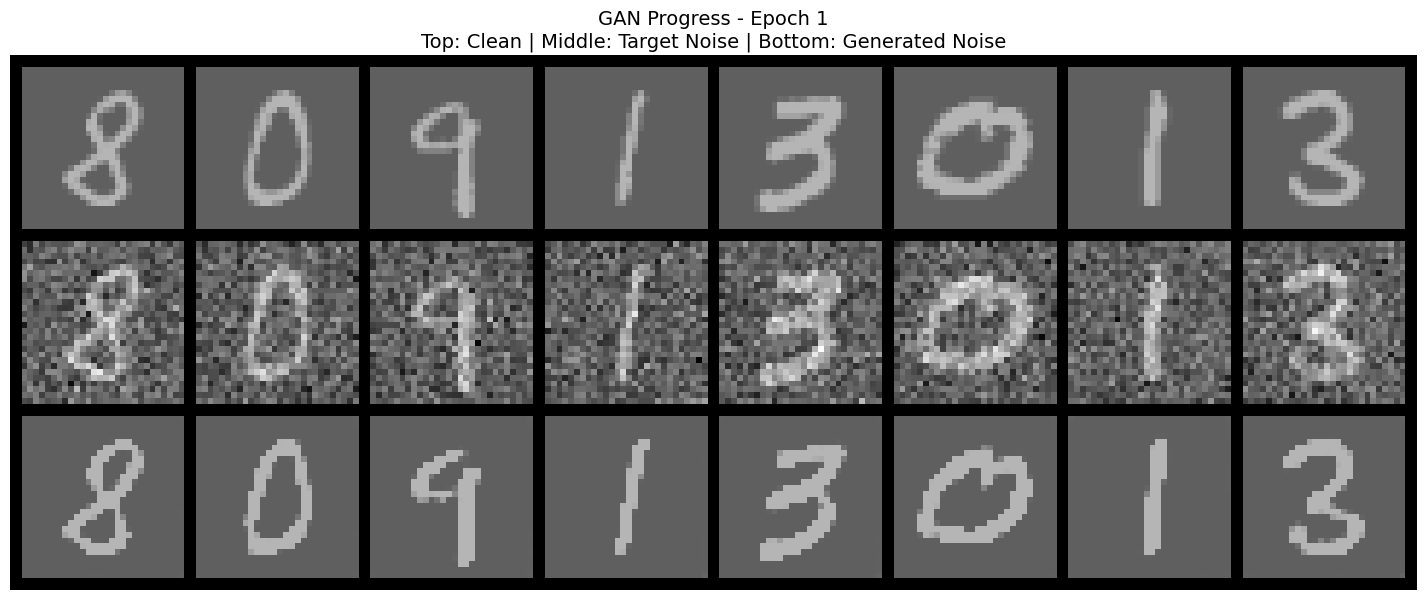

Epoch [2/10] | Train D Loss: 0.0117, G Loss: 9.6084 | Val D Loss: 0.0030, G Loss: 9.6510


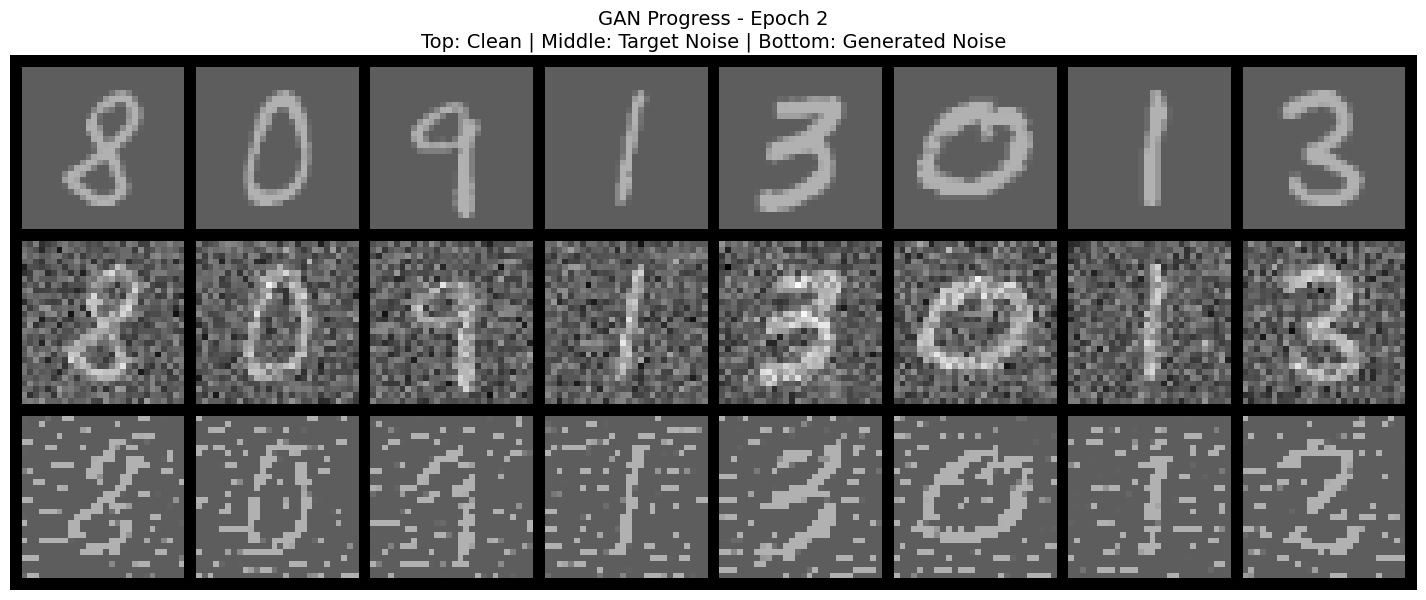

Epoch [3/10] | Train D Loss: 0.0018, G Loss: 10.0348 | Val D Loss: 0.0010, G Loss: 10.3744


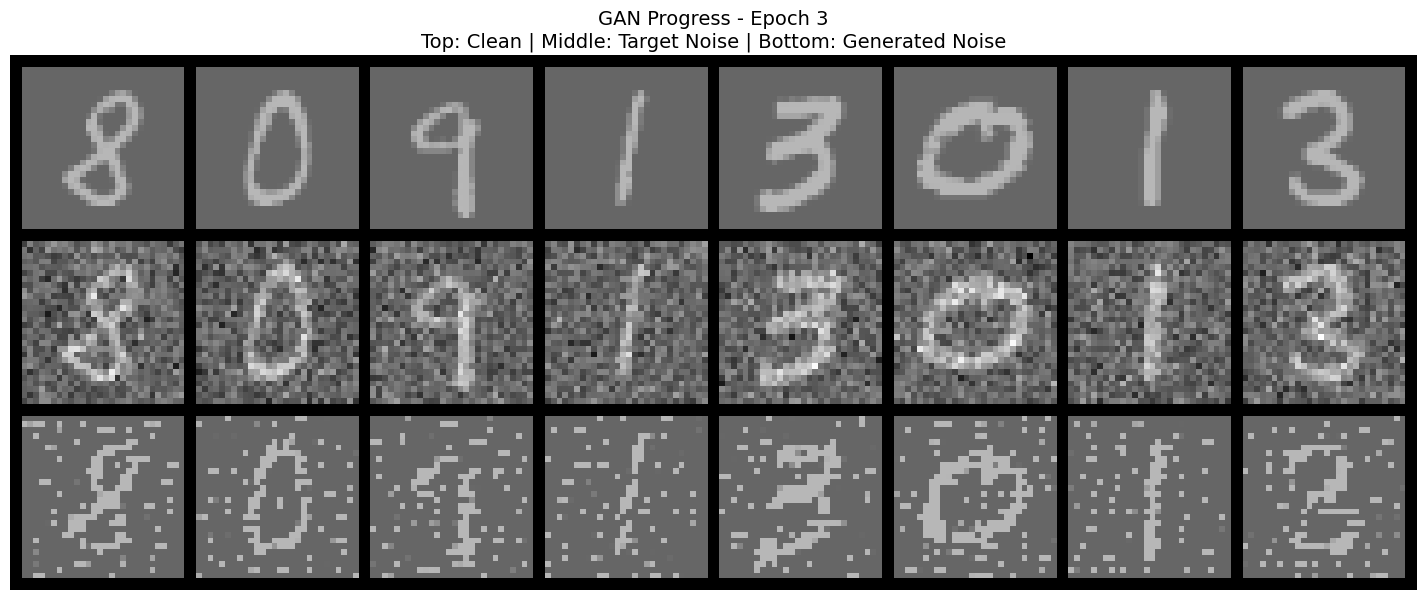

Epoch [4/10] | Train D Loss: 0.0009, G Loss: 10.8203 | Val D Loss: 0.0008, G Loss: 10.7969


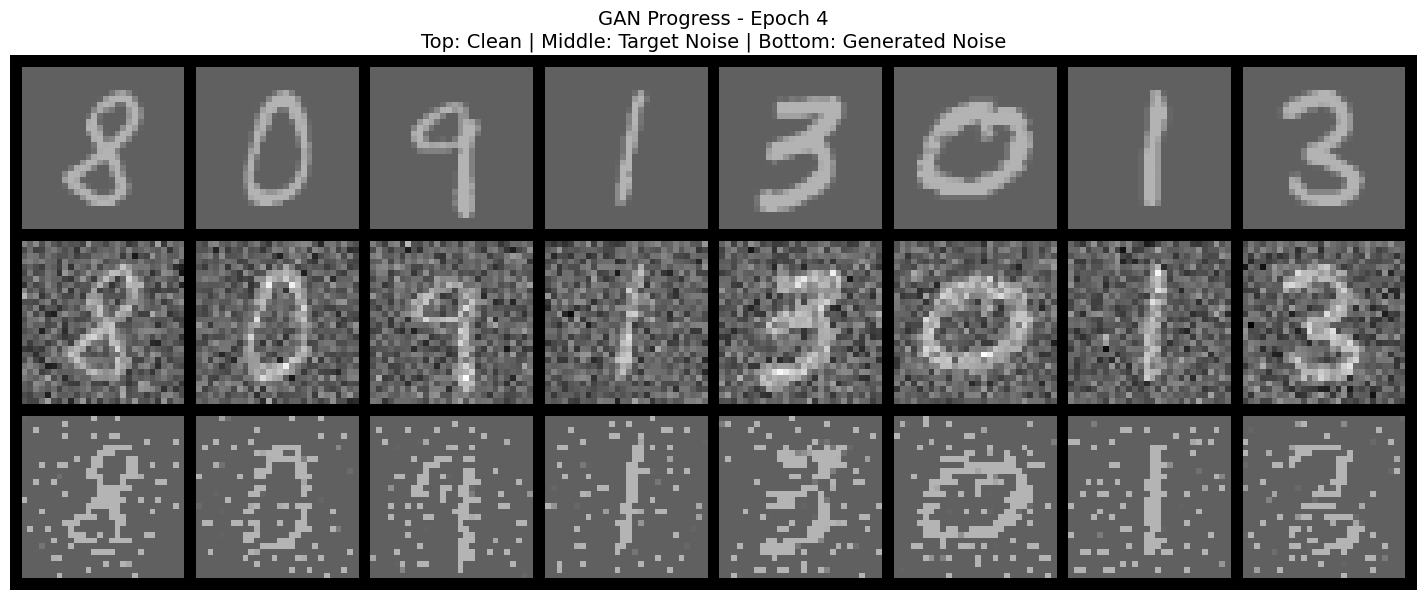

Epoch [5/10] | Train D Loss: 0.0006, G Loss: 11.3871 | Val D Loss: 0.0004, G Loss: 11.8647


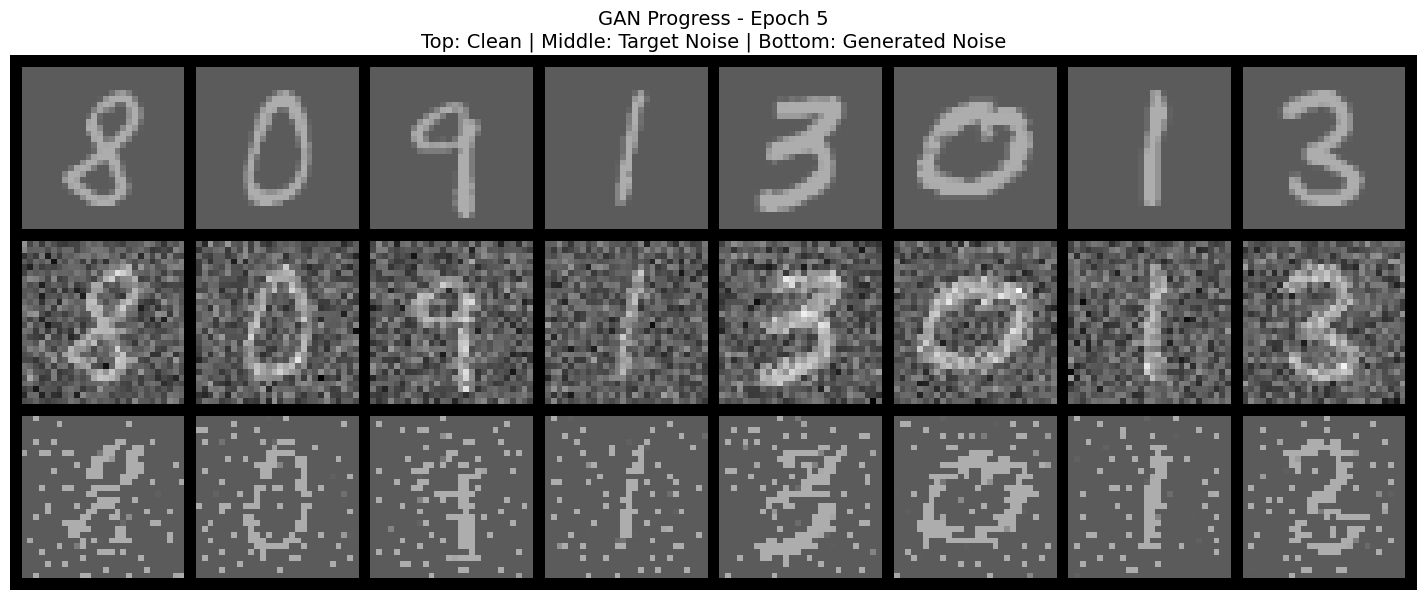

Epoch [6/10] | Train D Loss: 0.0003, G Loss: 11.9615 | Val D Loss: 0.0004, G Loss: 12.7346


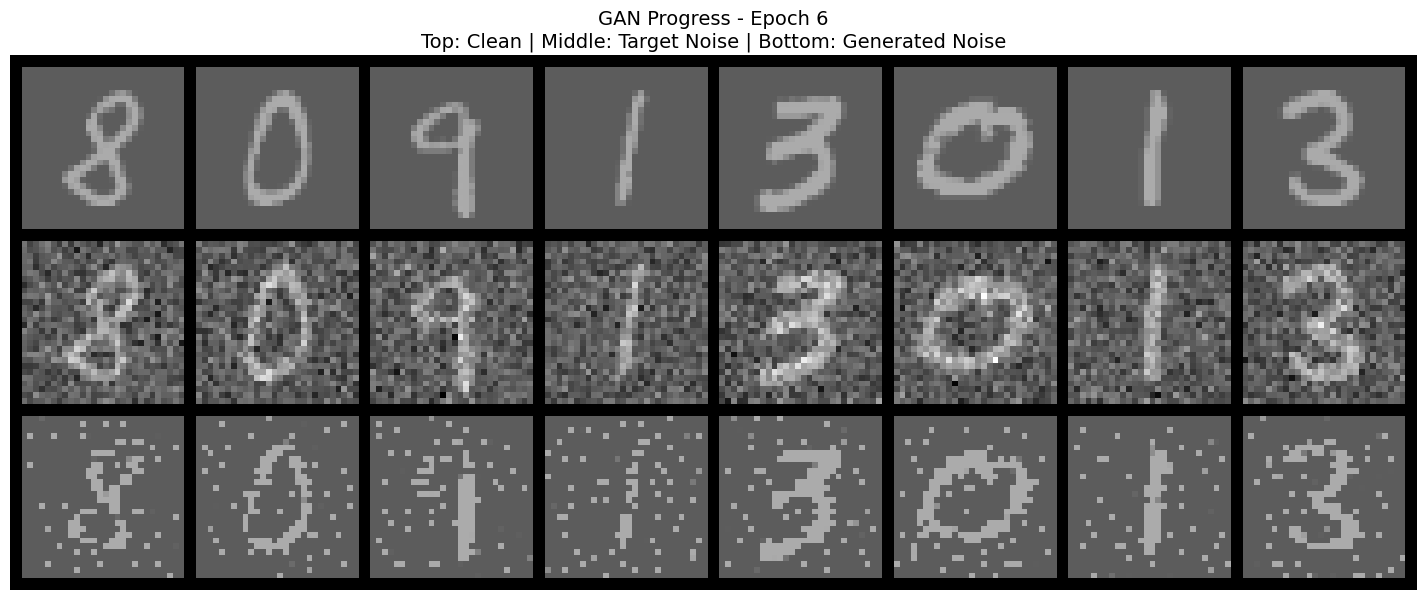

Epoch [7/10] | Train D Loss: 0.0002, G Loss: 12.4522 | Val D Loss: 0.0002, G Loss: 12.9172


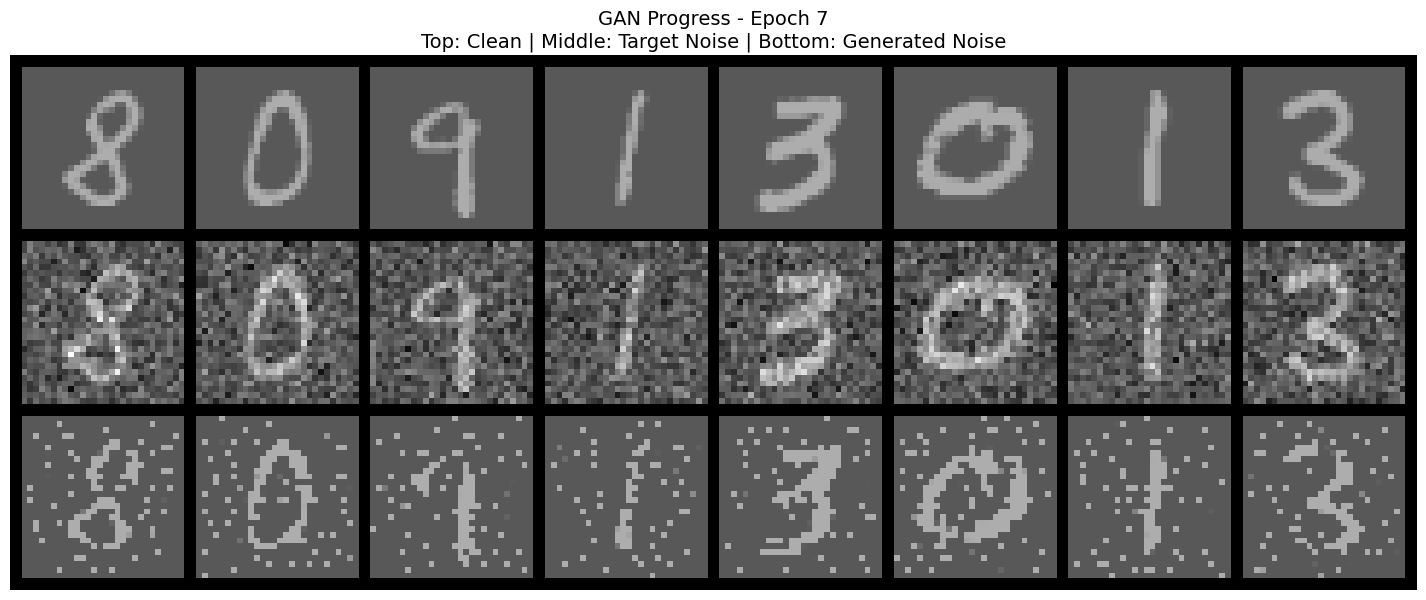

Epoch [8/10] | Train D Loss: 0.0002, G Loss: 12.9891 | Val D Loss: 0.0001, G Loss: 13.2272


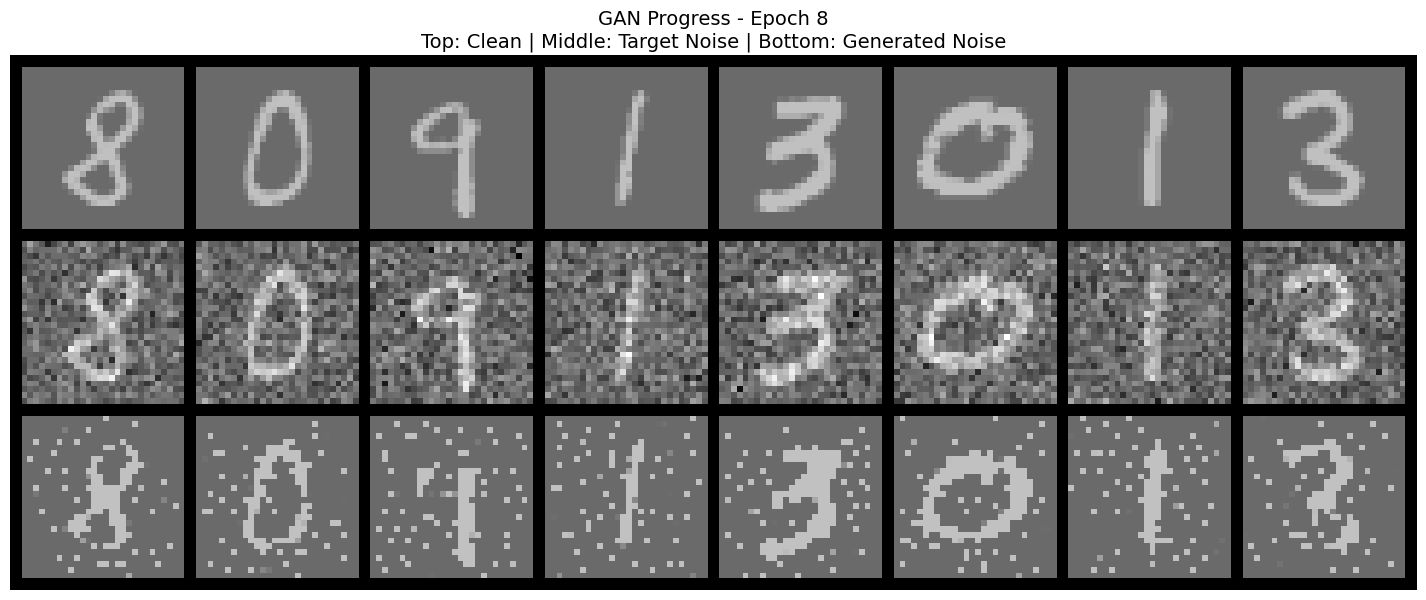

Epoch [9/10] | Train D Loss: 0.0001, G Loss: 13.4776 | Val D Loss: 0.0001, G Loss: 14.2232


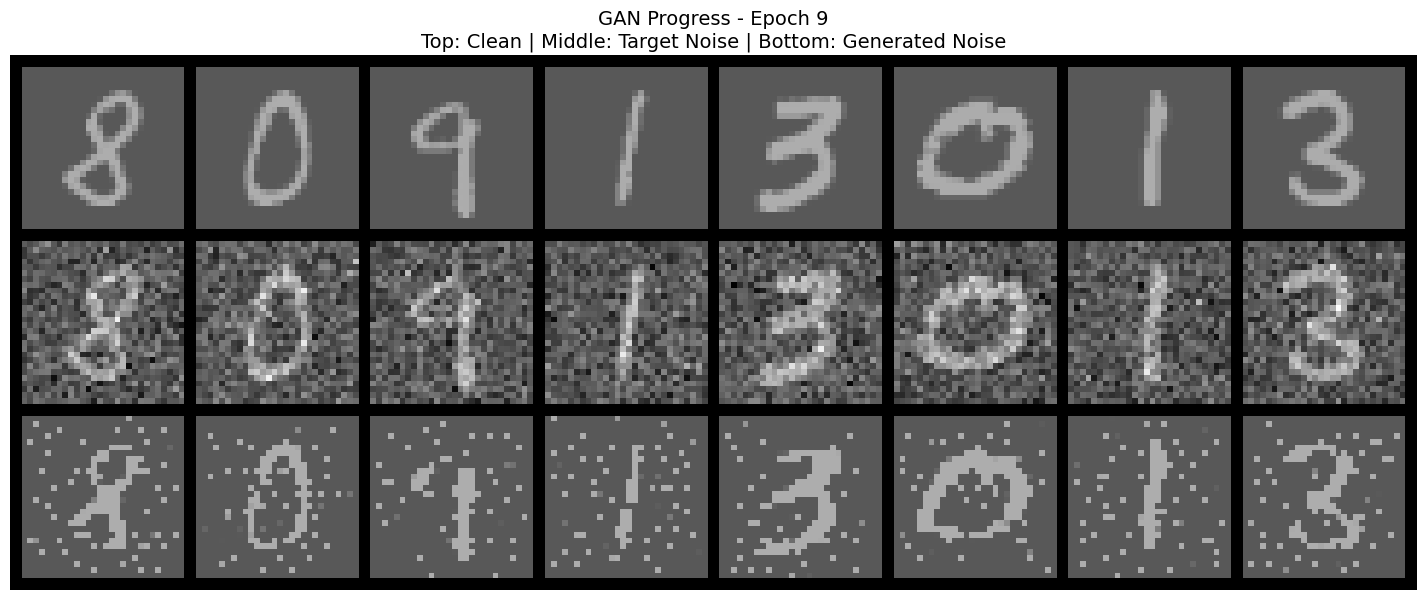

Epoch [10/10] | Train D Loss: 0.0001, G Loss: 13.7486 | Val D Loss: 0.0000, G Loss: 13.8243


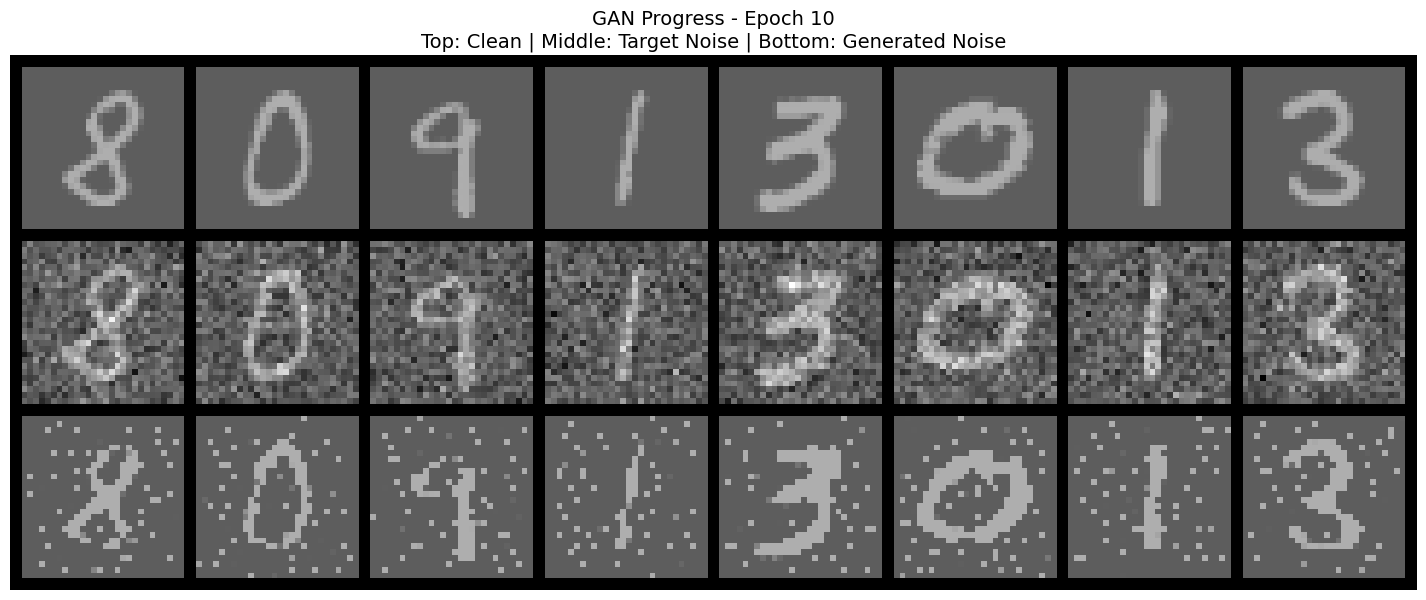

In [ ]:
import torch.nn.functional as F
import torch.optim as optim
import math

# 1. The Generator (The Counterfeiter)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 2 channels (1 for clean image, 1 for random latent noise map)
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=3, padding=1),
            nn.Sigmoid() # Keeps pixel values between 0 and 1
        )

    def forward(self, clean_image, latent_noise):
        # Stack the clean image and random noise together
        x = torch.cat([clean_image, latent_noise], dim=1)
        return self.net(x)

# 2. The Discriminator (The Detective)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 2 channels (1 for clean image, 1 for the noisy image being judged)
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1), # 28x28 -> 14x14
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid() # Outputs a probability: 1 = Real, 0 = Fake
        )

    def forward(self, clean_image, noisy_image):
        # Look at both the clean and noisy image together
        x = torch.cat([clean_image, noisy_image], dim=1)
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCELoss()
generator = Generator().to(device)
discriminator = Discriminator().to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss() # Needed strictly for the PSNR calculation

epochs = 10

for epoch in range(epochs):
    generator.train()
    discriminator.train()

    train_d_loss = 0.0
    train_g_loss = 0.0

    for i, (clean_imgs, real_noisy_imgs) in enumerate(train_loader):
        clean_imgs = clean_imgs.to(device)
        real_noisy_imgs = real_noisy_imgs.to(device)
        batch_size = clean_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        latent_noise = torch.randn_like(clean_imgs).to(device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        pred_real = discriminator(clean_imgs, real_noisy_imgs)
        loss_D_real = criterion(pred_real, real_labels)

        fake_noisy_imgs = generator(clean_imgs, latent_noise)
        pred_fake = discriminator(clean_imgs, fake_noisy_imgs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()
        train_d_loss += loss_D.item()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        pred_fake_for_G = discriminator(clean_imgs, fake_noisy_imgs)

        loss_G_bce = criterion(pred_fake_for_G, real_labels)
        loss_G_l1 = l1_loss(fake_noisy_imgs, real_noisy_imgs) * 10.0

        loss_G = loss_G_bce + loss_G_l1
        loss_G.backward()
        optimizer_G.step()
        train_g_loss += loss_G.item()

    generator.eval()
    discriminator.eval()
    val_d_loss = 0.0
    val_g_loss = 0.0

    with torch.no_grad():
        for clean_imgs, real_noisy_imgs in val_loader:
            clean_imgs = clean_imgs.to(device)
            real_noisy_imgs = real_noisy_imgs.to(device)
            batch_size = clean_imgs.size(0)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            latent_noise = torch.randn_like(clean_imgs).to(device)

            # Forward passes only
            fake_noisy_imgs = generator(clean_imgs, latent_noise)

            # Discriminator Validation Loss
            pred_real = discriminator(clean_imgs, real_noisy_imgs)
            pred_fake = discriminator(clean_imgs, fake_noisy_imgs)
            loss_D_real = criterion(pred_real, real_labels)
            loss_D_fake = criterion(pred_fake, fake_labels)
            val_d_loss += ((loss_D_real + loss_D_fake) / 2).item()

            # Generator Validation Loss
            loss_G_bce = criterion(pred_fake, real_labels)
            loss_G_l1 = l1_loss(fake_noisy_imgs, real_noisy_imgs) * 10.0
            val_g_loss += (loss_G_bce + loss_G_l1).item()

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train D Loss: {train_d_loss/len(train_loader):.4f}, G Loss: {train_g_loss/len(train_loader):.4f} | "
          f"Val D Loss: {val_d_loss/len(val_loader):.4f}, G Loss: {val_g_loss/len(val_loader):.4f}")

    visualize_progress(clean_imgs, real_noisy_imgs, fake_noisy_imgs, epoch=epoch+1, num_images=8)

In [ ]:
print("\nStarting Final Evaluation on Test Set...")
generator.eval()
test_psnr = 0.0
test_mse = 0.0

with torch.no_grad():
    for clean_imgs, real_noisy_imgs in test_loader:
        clean_imgs = clean_imgs.to(device)
        real_noisy_imgs = real_noisy_imgs.to(device)

        # Generate random noise for the test set
        latent_noise = torch.randn_like(clean_imgs).to(device)
        fake_noisy_imgs = generator(clean_imgs, latent_noise)

        # Calculate MSE between the GAN's output and the ground truth noisy image
        batch_mse = mse_loss(fake_noisy_imgs, real_noisy_imgs).item()
        test_mse += batch_mse

        # Calculate PSNR (Max pixel value is 1.0)
        if batch_mse > 0:
            batch_psnr = 10 * math.log10(1.0 / batch_mse)
            test_psnr += batch_psnr

avg_test_mse = test_mse / len(test_loader)
avg_test_psnr = test_psnr / len(test_loader)

print(f"Training Complete!")
print(f"Final Test MSE:  {avg_test_mse:.4f}")
print(f"Final Test PSNR: {avg_test_psnr:.2f} dB")


Starting Final Evaluation on Test Set...
Training Complete!
Final Test MSE:  0.1610
Final Test PSNR: 7.93 dB
